<a href="https://colab.research.google.com/github/joaocanaslopes/Exercises_AVD/blob/main/exercise_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

In [11]:
import pandas as pd

url = "https://raw.githubusercontent.com/isa-ulisboa/greends-avcad-2026/main/examples/EFIplus_medit.zip"

df = pd.read_csv(url, compression="zip", sep=";")

df.head(20)

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
5,ES_02_0005,40.732830,-2.078003,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
6,ES_02_0006,40.788013,-2.152441,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
7,ES_02_0007,40.793682,-2.285236,Spain,Tejo,0,1,1,1,0,...,0,1,0,0,0,0,1,0,0,0
8,ES_02_0008,40.747652,-2.394504,Spain,Tejo,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
9,ES_02_0010,40.807161,-1.838133,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


### Visualizing Distributions of Environmental Variables

We will create histograms and Q-Q plots for the specified continuous environmental variables to visually assess their distributions and determine if any transformations are needed for parametric tests.

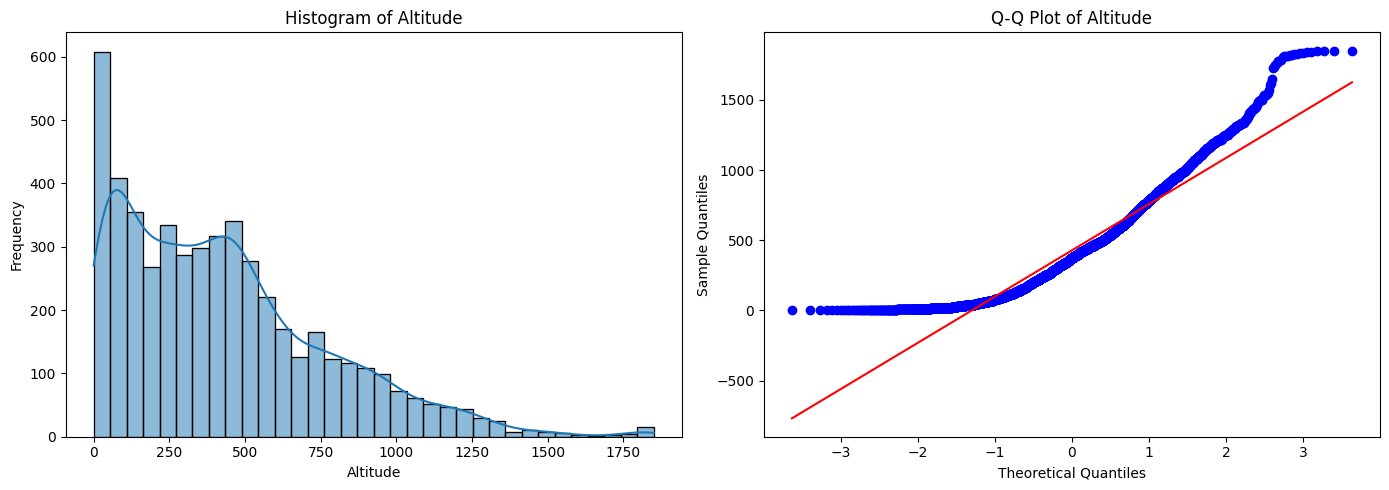

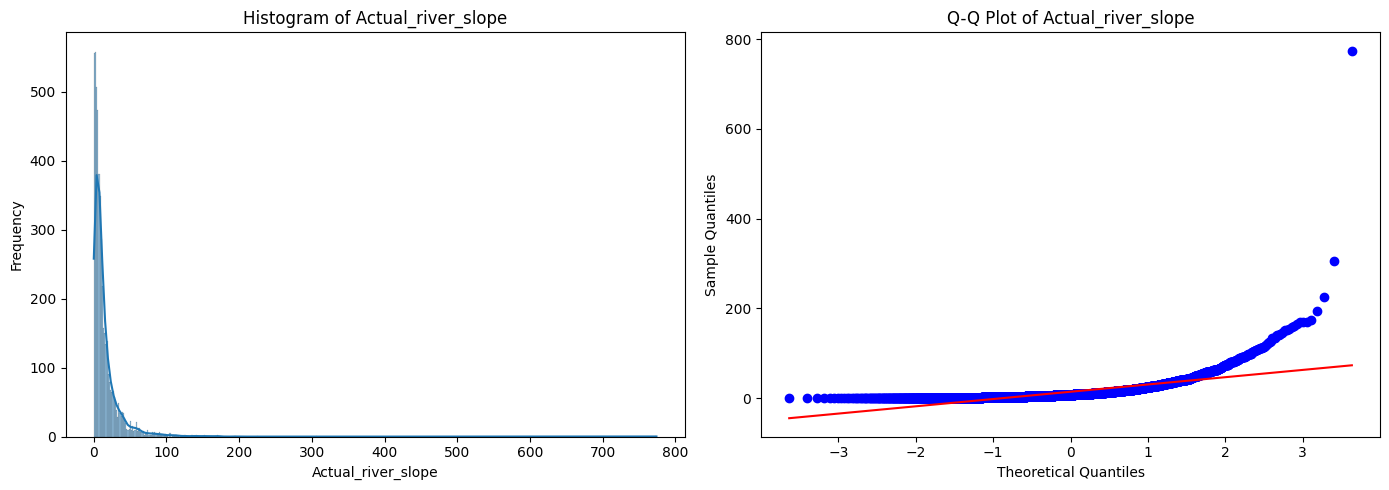

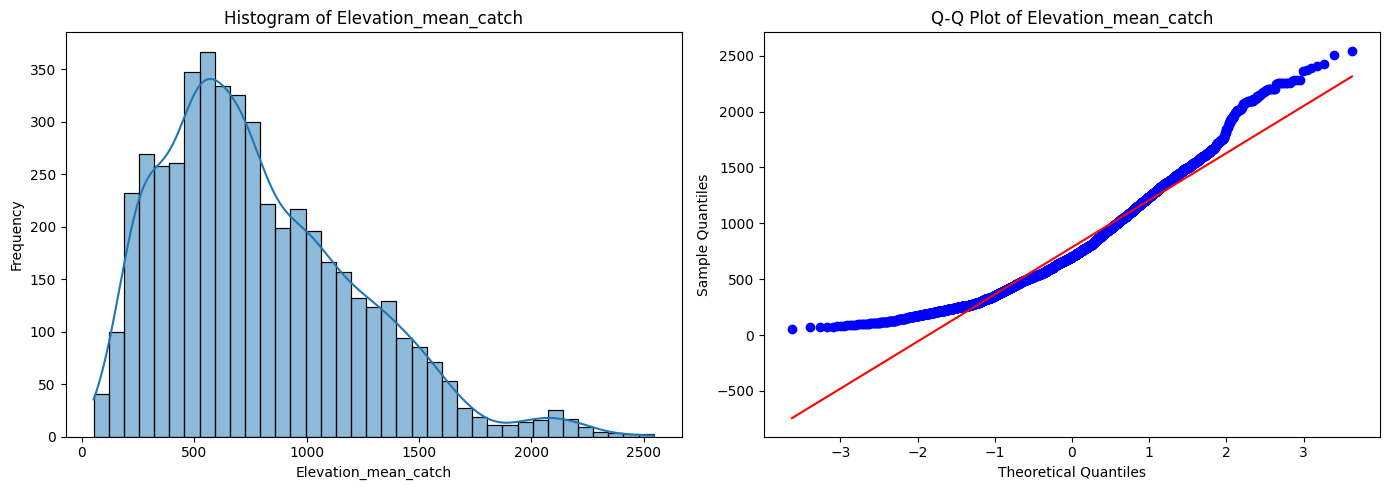

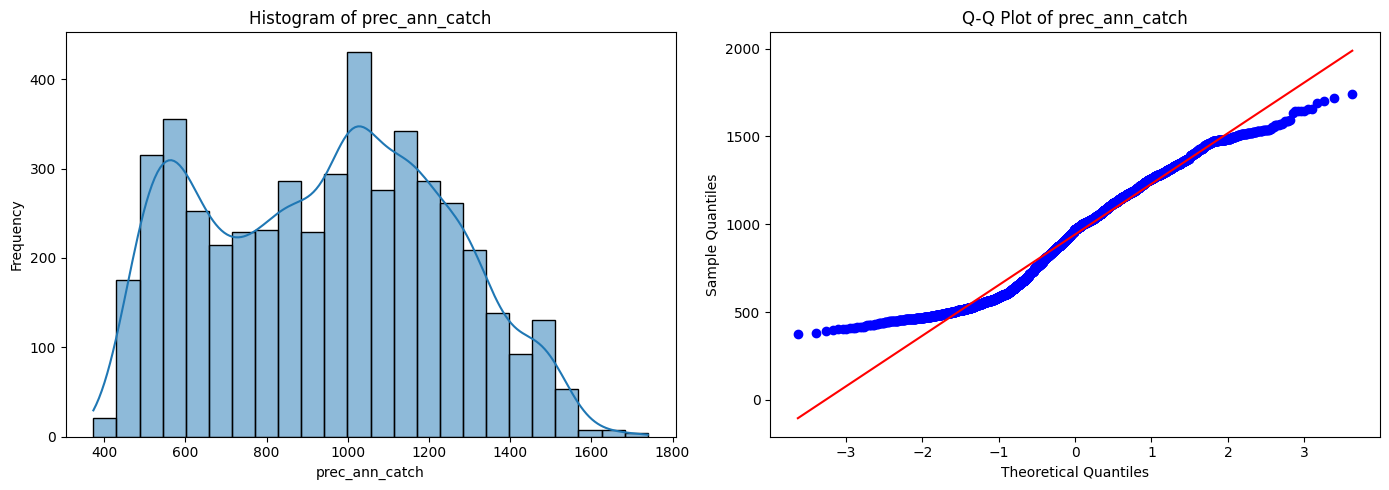

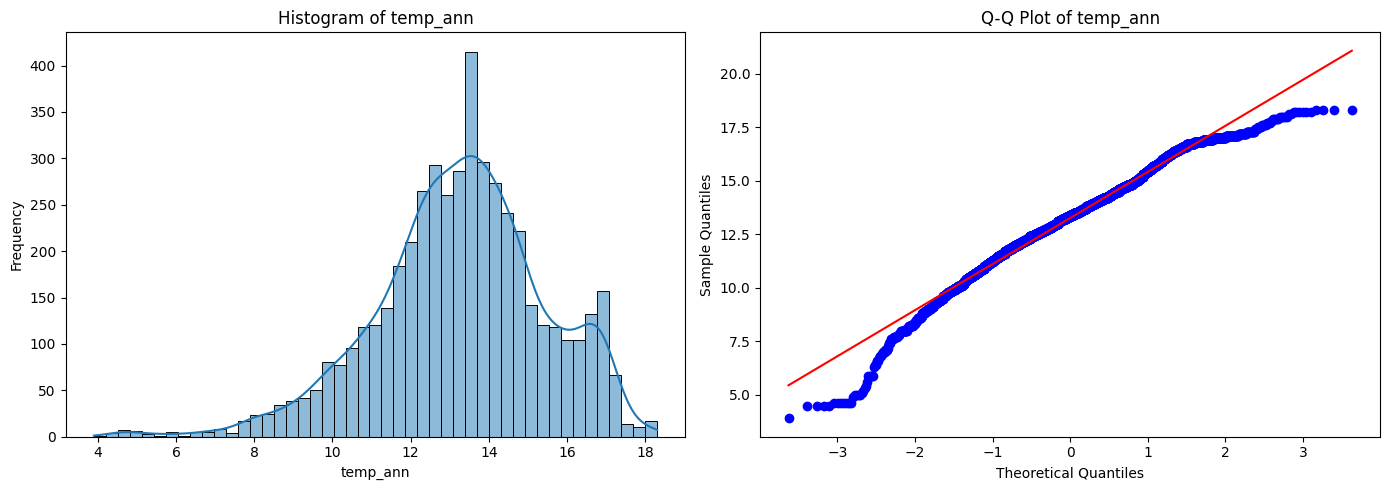

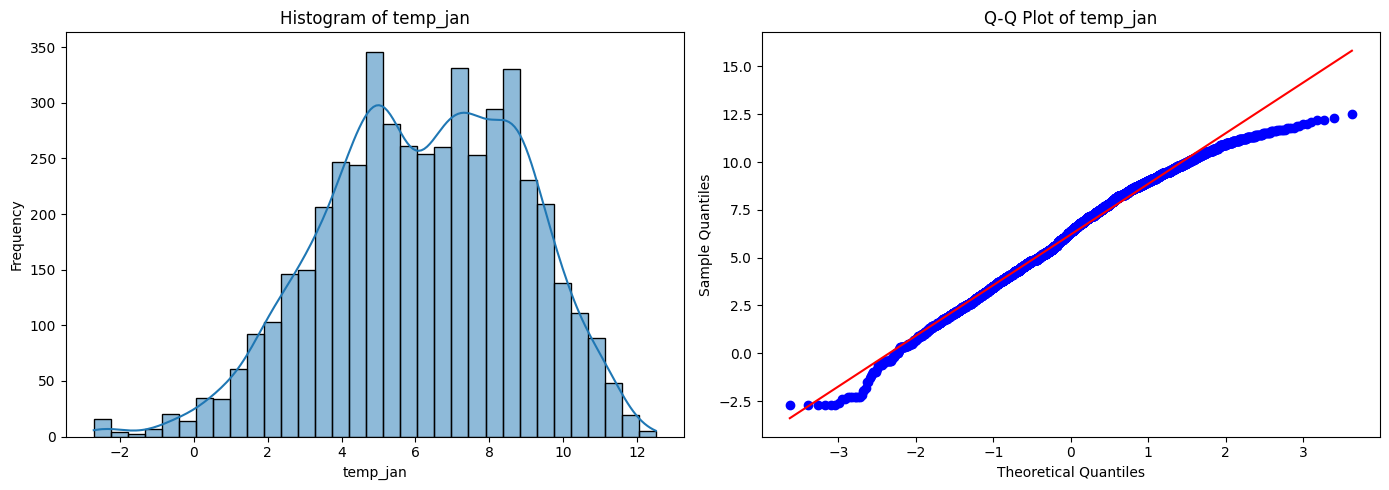

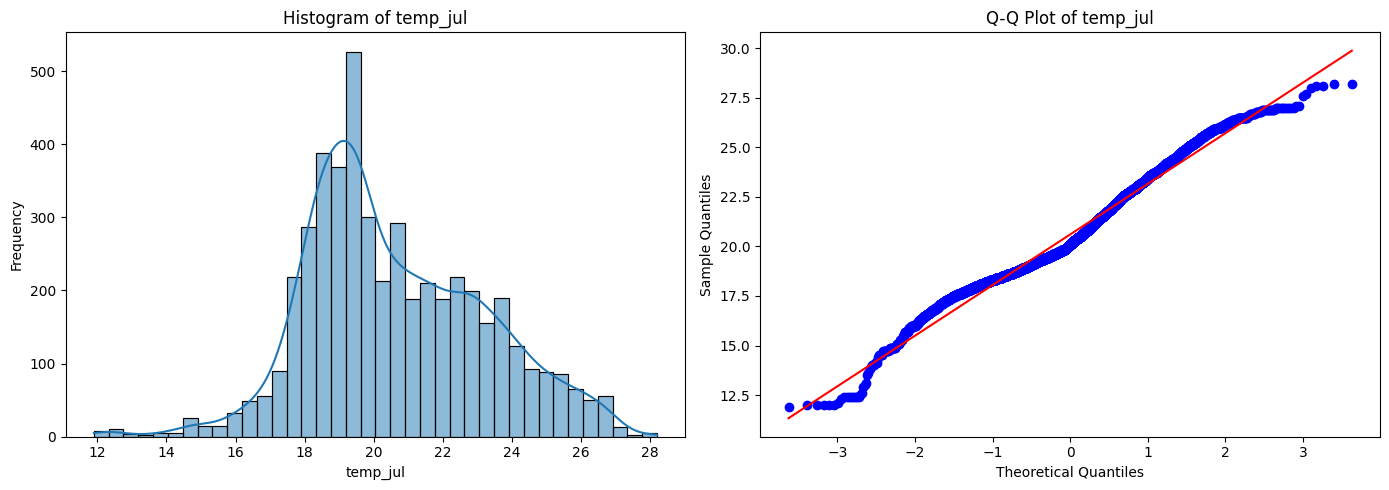

In [3]:
environmental_vars = [
    'Altitude',
    'Actual_river_slope',
    'Elevation_mean_catch',
    'prec_ann_catch',
    'temp_ann',
    'temp_jan',
    'temp_jul'
]

for col in environmental_vars:
    if col in df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Histogram
        sns.histplot(df[col].dropna(), kde=True, ax=axes[0])
        axes[0].set_title(f'Histogram of {col}')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Frequency')

        # Q-Q plot
        stats.probplot(df[col].dropna(), dist="norm", plot=axes[1])
        axes[1].set_title(f'Q-Q Plot of {col}')
        axes[1].set_xlabel('Theoretical Quantiles')
        axes[1].set_ylabel('Sample Quantiles')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Column '{col}' not found in the DataFrame.")

### Calculating Skewness

We will now calculate the skewness for each environmental variable to quantitatively assess their distributions. Skewness values significantly different from 0 (e.g., typically above +1 or below -1) often indicate a need for transformation.

In [4]:
print("Skewness for environmental variables:")
for col in environmental_vars:
    if col in df.columns:
        skewness_val = df[col].skew()
        print(f"- {col}: {skewness_val:.4f}")
    else:
        print(f"- {col}: Column not found.")

Skewness for environmental variables:
- Altitude: 1.0018
- Actual_river_slope: 10.3183
- Elevation_mean_catch: 0.8490
- prec_ann_catch: 0.0582
- temp_ann: -0.4765
- temp_jan: -0.2879
- temp_jul: 0.2880


### Outlier Detection and Data Transformation

Based on the skewness values, `Actual_river_slope` has a very high positive skewness (10.32), and `Altitude` (1.00) and `Elevation_mean_catch` (0.85) also show moderate positive skewness. These variables are good candidates for outlier detection and transformation.

We will use now the Isolation Forest algorithm to detect outliers in `Actual_river_slope` and visualize them using a box plot. Then, I will apply a logarithmic transformation to `Actual_river_slope` and `Altitude` due to their positive skewness, and re-evaluate their distributions.


--- Processing Actual_river_slope ---


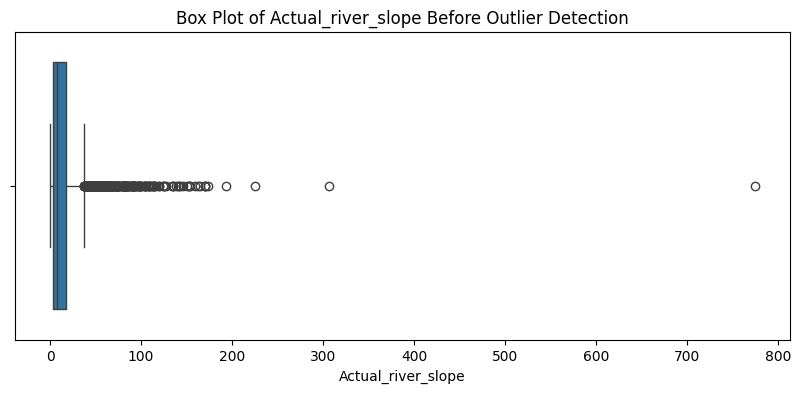

Number of outliers detected in Actual_river_slope: 1041

--- Processing Altitude ---


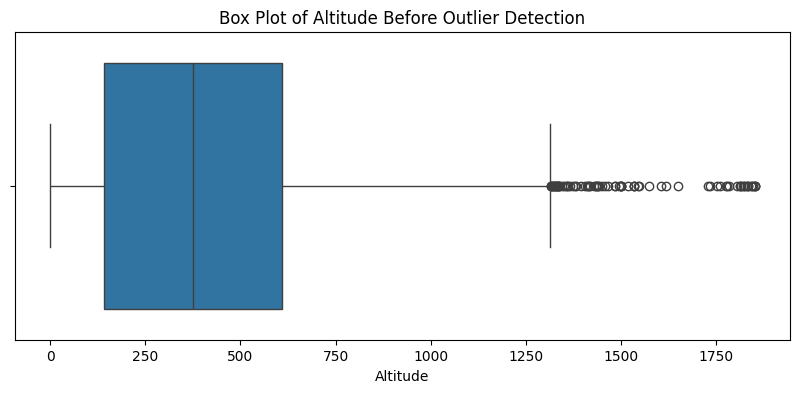

Number of outliers detected in Altitude: 1406

--- Processing Elevation_mean_catch ---


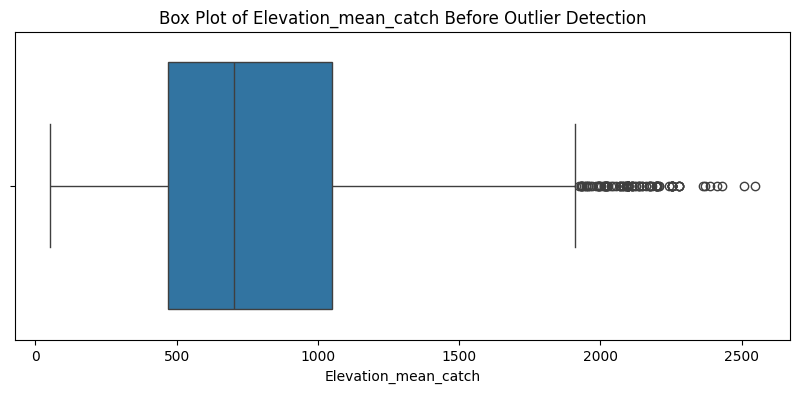

Number of outliers detected in Elevation_mean_catch: 1278


In [5]:
# Identify highly skewed variables for outlier detection and transformation
highly_skewed_vars = ['Actual_river_slope', 'Altitude', 'Elevation_mean_catch']

for col in highly_skewed_vars:
    if col in df.columns:
        print(f"\n--- Processing {col} ---")
        # Visualize before outlier detection
        plt.figure(figsize=(10, 4))
        sns.boxplot(x=df[col].dropna())
        plt.title(f'Box Plot of {col} Before Outlier Detection')
        plt.show()

        # Outlier detection using Isolation Forest
        # For simplicity, we'll fit on the non-null values
        data_for_if = df[col].dropna().values.reshape(-1, 1)
        if len(data_for_if) > 1: # Ensure there's enough data for IsolationForest
            iso_forest = IsolationForest(random_state=42)
            outliers = iso_forest.fit_predict(data_for_if)
            # -1 for outliers, 1 for inliers
            df[f'{col}_outlier'] = np.nan # Initialize column
            df.loc[df[col].notna(), f'{col}_outlier'] = outliers

            num_outliers = (df[f'{col}_outlier'] == -1).sum()
            print(f"Number of outliers detected in {col}: {num_outliers}")

            # Visualize outliers (optional, for verification)
            # df_plot = df[[col, f'{col}_outlier']].dropna()
            # plt.figure(figsize=(10, 6))
            # sns.scatterplot(x=df_plot.index, y=df_plot[col], hue=df_plot[f'{col}_outlier'], palette='coolwarm')
            # plt.title(f'Outliers in {col} (Isolation Forest)')
            # plt.show()
        else:
            print(f"Not enough data in {col} to run Isolation Forest.")

### Applying Data Transformations

Based on the visual inspection and skewness values, we will apply transformations to the following variables:

*   `Actual_river_slope`: Highly positively skewed, so we'll try a logarithmic transformation (`np.log1p` which handles zero values).
*   `Altitude`: Moderately positively skewed, also suitable for a logarithmic transformation (`np.log1p`).
*   `Elevation_mean_catch`: Moderately positively skewed, will also apply `np.log1p`.

'Actual_river_slope' transformed to 'Actual_river_slope_log_transformed'.
'Altitude' transformed to 'Altitude_log_transformed'.
'Elevation_mean_catch' transformed to 'Elevation_mean_catch_log_transformed'.


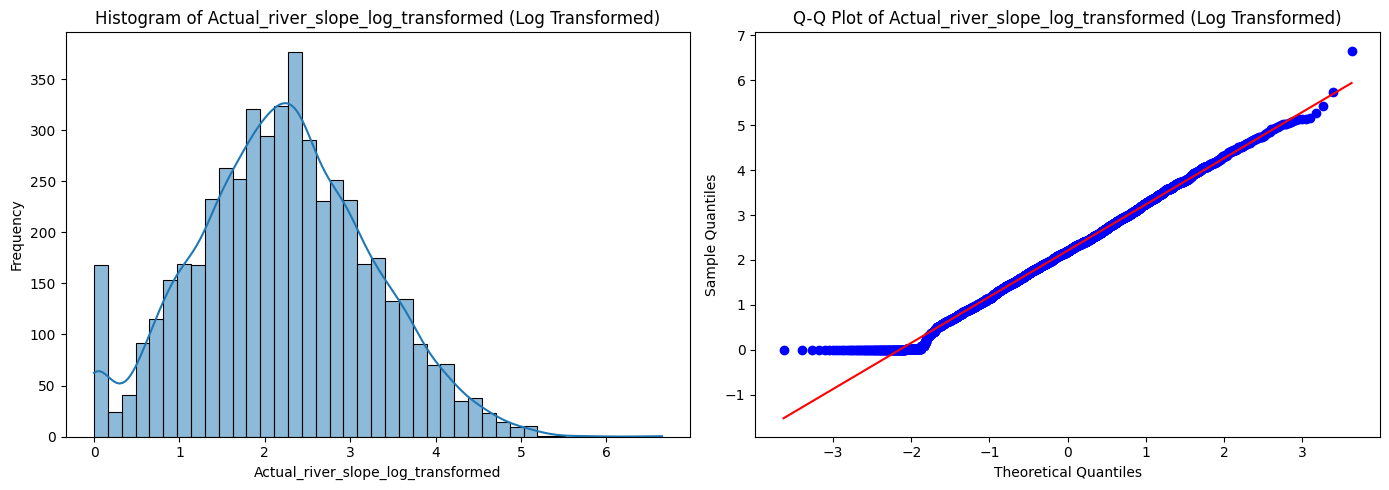

New skewness for Actual_river_slope_log_transformed: 0.0878


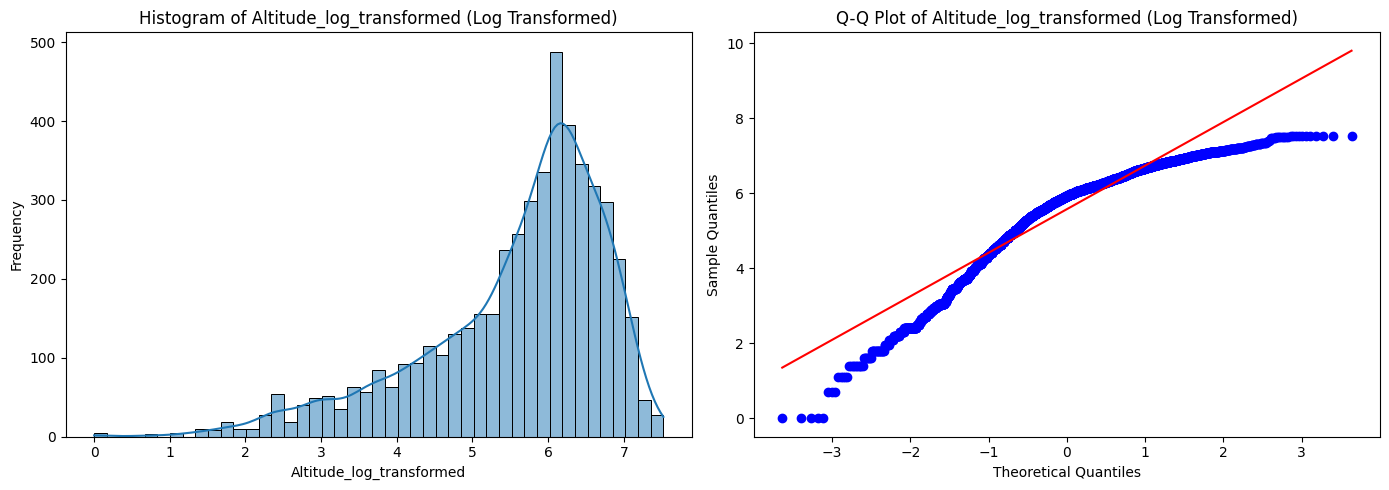

New skewness for Altitude_log_transformed: -1.1845


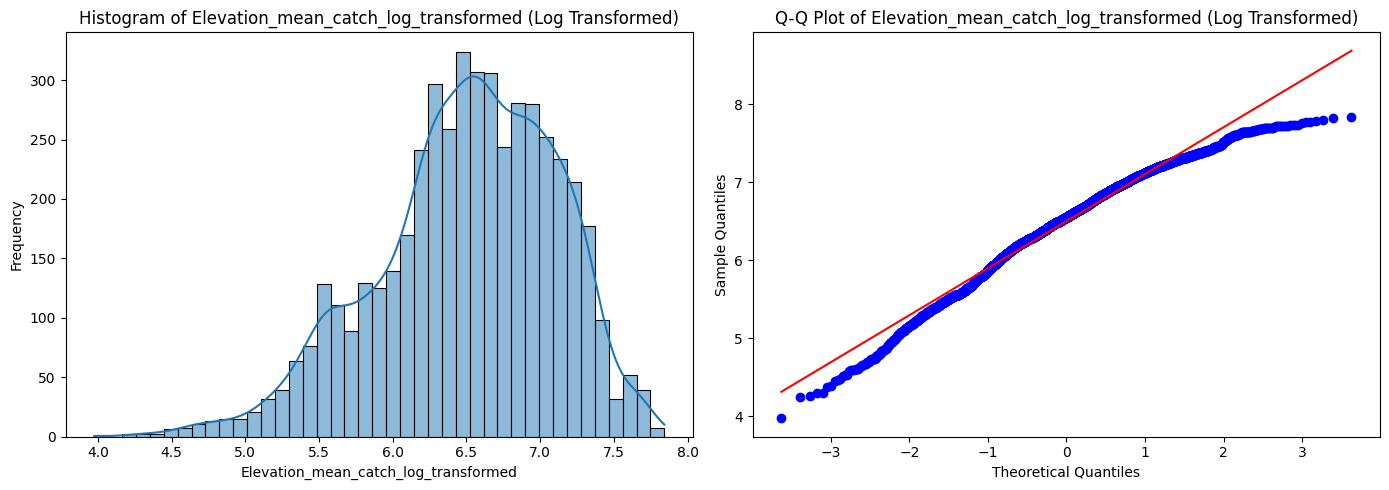

New skewness for Elevation_mean_catch_log_transformed: -0.5437


In [6]:
# Apply logarithmic transformation to highly skewed variables
transformed_vars = {}

for col in ['Actual_river_slope', 'Altitude', 'Elevation_mean_catch']:
    if col in df.columns:
        # np.log1p(x) is equivalent to log(1+x), useful for data that might contain zeros
        df[f'{col}_log_transformed'] = np.log1p(df[col])
        transformed_vars[col] = f'{col}_log_transformed'
        print(f"'{col}' transformed to '{col}_log_transformed'.")
    else:
        print(f"Column '{col}' not found for transformation.")

# Re-visualize the distributions of the transformed variables
for original_col, transformed_col in transformed_vars.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram of transformed variable
    sns.histplot(df[transformed_col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram of {transformed_col} (Log Transformed)')
    axes[0].set_xlabel(transformed_col)
    axes[0].set_ylabel('Frequency')

    # Q-Q plot of transformed variable
    stats.probplot(df[transformed_col].dropna(), dist="norm", plot=axes[1])
    axes[1].set_title(f'Q-Q Plot of {transformed_col} (Log Transformed)')
    axes[1].set_xlabel('Theoretical Quantiles')
    axes[1].set_ylabel('Sample Quantiles')

    plt.tight_layout()
    plt.show()

    # Calculate new skewness for transformed variable
    new_skewness = df[transformed_col].skew()
    print(f"New skewness for {transformed_col}: {new_skewness:.4f}")

### Implementing Box-Cox Transformation

Now, let's apply the Box-Cox transformation to the same highly skewed variables and compare its effects on the distribution. The Box-Cox transformation can often achieve a distribution closer to normal than a simple logarithmic transformation, as it optimizes a `lambda` parameter for the best transformation. Note that Box-Cox requires strictly positive data; if any values are zero or negative, they will need to be handled (e.g., by adding a small constant or using `boxcox1p`).

'Elevation_mean_catch' transformed to 'Elevation_mean_catch_boxcox_transformed' with lambda = 0.3387.


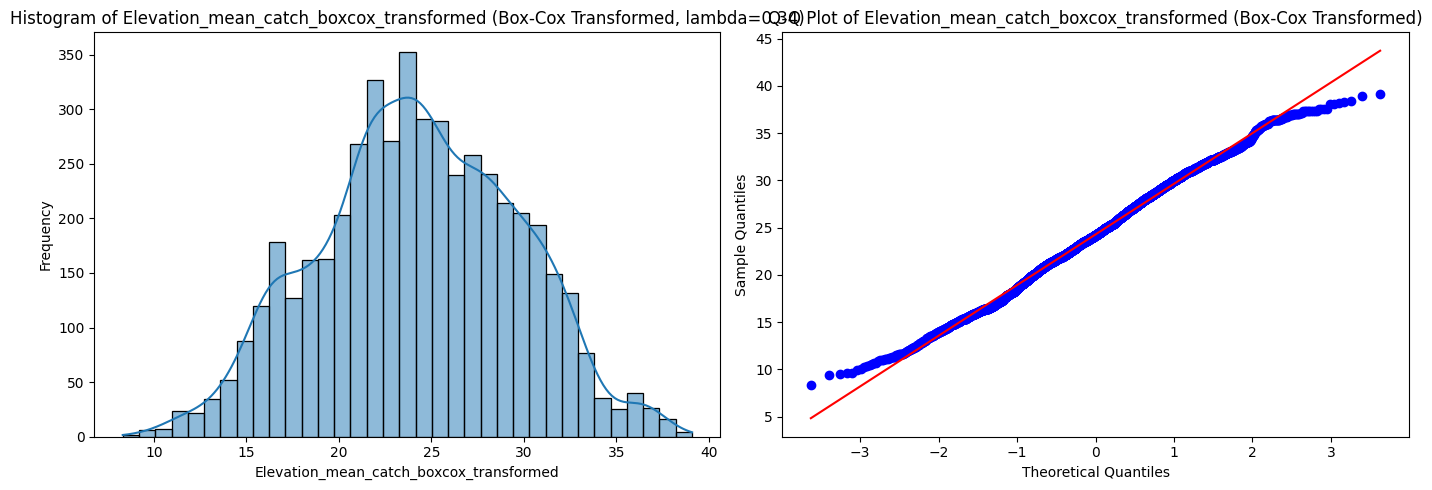

New skewness for Elevation_mean_catch_boxcox_transformed: -0.0302


In [7]:
boxcox_transformed_vars = {}

for col in ['Actual_river_slope', 'Altitude', 'Elevation_mean_catch']:
    if col in df.columns:
        # Box-Cox requires strictly positive data. We'll check for this.
        # If there are zero values, we can use boxcox1p or add a small constant.
        # Given the nature of these variables (altitude, slope), they are likely positive.
        # If not, a ValueError will occur.
        data_to_transform = df[col].dropna()

        if (data_to_transform <= 0).any():
            print(f"Warning: Column '{col}' contains non-positive values. Box-Cox transformation requires positive data. Skipping Box-Cox for this column.")
            continue

        # Apply Box-Cox transformation
        transformed_data, lambda_val = stats.boxcox(data_to_transform)
        df[f'{col}_boxcox_transformed'] = np.nan # Initialize column
        df.loc[df[col].notna(), f'{col}_boxcox_transformed'] = transformed_data
        boxcox_transformed_vars[col] = (f'{col}_boxcox_transformed', lambda_val)
        print(f"'{col}' transformed to '{col}_boxcox_transformed' with lambda = {lambda_val:.4f}.")
    else:
        print(f"Column '{col}' not found for Box-Cox transformation.")

# Re-visualize the distributions of the Box-Cox transformed variables
for original_col, (transformed_col, lambda_val) in boxcox_transformed_vars.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram of Box-Cox transformed variable
    sns.histplot(df[transformed_col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram of {transformed_col} (Box-Cox Transformed, lambda={lambda_val:.2f})')
    axes[0].set_xlabel(transformed_col)
    axes[0].set_ylabel('Frequency')

    # Q-Q plot of Box-Cox transformed variable
    stats.probplot(df[transformed_col].dropna(), dist="norm", plot=axes[1])
    axes[1].set_title(f'Q-Q Plot of {transformed_col} (Box-Cox Transformed)')
    axes[1].set_xlabel('Theoretical Quantiles')
    axes[1].set_ylabel('Sample Quantiles')

    plt.tight_layout()
    plt.show()

    # Calculate new skewness for Box-Cox transformed variable
    new_skewness = df[transformed_col].skew()
    print(f"New skewness for {transformed_col}: {new_skewness:.4f}")

### Calculating Species Richness

We will create a new column named `Species_Richness` by summing the presence/absence (`0` or `1`) across all species columns. As per the instructions, the first species column is considered to be 'Abramis brama', and all subsequent columns to its right are assumed to be species presence/absence data.

In [13]:
if 'Abramis brama' in df.columns:
    # Find the index of 'Abramis brama'
    start_species_col_idx = df.columns.get_loc('Abramis brama')
    # Select all columns from this index onwards as species columns
    species_columns = df.columns[start_species_col_idx:]

    # Ensure only 0/1 type columns are included in species calculation
    # Filter to only include columns that are numeric and contain only 0s and 1s (and potentially NaNs)
    final_species_cols = []
    for col in species_columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            unique_vals = df[col].dropna().unique()
            if len(unique_vals) <= 2 and all(v in [0, 1] for v in unique_vals):
                final_species_cols.append(col)

    if final_species_cols:
        df['Species_Richness'] = df[final_species_cols].sum(axis=1)
        print("Successfully created 'Species_Richness' column based on identified species columns starting from 'Abramis brama'.")
    else:
        print("Warning: 'Abramis brama' was found, but no subsequent columns were identified as 0/1 presence/absence species data. 'Species_Richness' not created.")

elif 'Abramis brama' not in df.columns:
    print("Warning: Column 'Abramis brama' not found in the DataFrame. Attempting to infer species columns more broadly.")

    # Fallback: Infer species columns by identifying columns with only 0s and 1s, excluding known non-species columns.

    # List of known non-species related columns (from context and common sense)
    known_non_species_cols = [
        'Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name',
        'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol',
        'Altitude', 'Actual_river_slope', 'Elevation_mean_catch', 'prec_ann_catch',
        'temp_ann', 'temp_jan', 'temp_jul'
    ]
    # Also exclude columns created during transformations and outlier detection
    generated_cols = [col for col in df.columns if '_log_transformed' in col or '_boxcox_transformed' in col or '_outlier' in col]

    all_excluded_cols = known_non_species_cols + generated_cols

    inferred_species_cols = []
    for col in df.columns:
        if col not in all_excluded_cols:
            if pd.api.types.is_numeric_dtype(df[col]):
                unique_vals = df[col].dropna().unique()
                if len(unique_vals) <= 2 and all(v in [0, 1] for v in unique_vals):
                    inferred_species_cols.append(col)

    if inferred_species_cols:
        df['Species_Richness'] = df[inferred_species_cols].sum(axis=1)
        print(f"Successfully created 'Species_Richness' column using {len(inferred_species_cols)} inferred species columns.")
        print("Top 5 inferred species columns:", inferred_species_cols[:5])
    else:
        print("Error: Could not identify any species (0/1 presence/absence) columns in the DataFrame. 'Species_Richness' not created.")

# Display the first few rows with the new Species_Richness column
print("\nDataFrame head with 'Species_Richness' column:")
display(df[['Site_code', 'Species_Richness']].head(20))

Successfully created 'Species_Richness' column based on identified species columns starting from 'Abramis brama'.

DataFrame head with 'Species_Richness' column:


,Site_code,Species_Richness
0,ES_01_0002,1
1,ES_02_0001,1
2,ES_02_0002,1
3,ES_02_0003,2
4,ES_02_0004,2
5,ES_02_0005,4
6,ES_02_0006,4
7,ES_02_0007,6
8,ES_02_0008,4
9,ES_02_0010,1


### Bivariate Outlier Detection

We will check for bivariate outliers in the relationship between Mean Annual Temperature (`temp_ann`) and `Species_Richness`. I'll first use a scatter plot for visual inspection, and then apply a bivariate Isolation Forest to detect and plot the outliers.

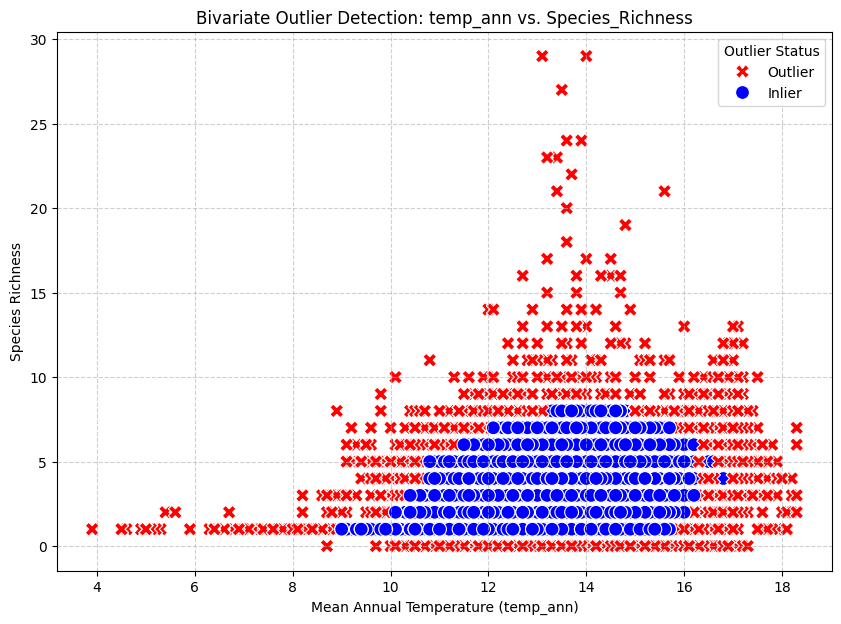

Number of bivariate outliers detected: 1209


In [16]:
data_for_bivariate_if = df[['temp_ann', 'Species_Richness']].dropna()

if not data_for_bivariate_if.empty:
    # Initialize and fit Isolation Forest
    # contamination='auto' estimates the proportion of outliers in the data
    bivariate_iso_forest = IsolationForest(random_state=42, contamination='auto')
    bivariate_outliers = bivariate_iso_forest.fit_predict(data_for_bivariate_if)

    # Add outlier status to the DataFrame for plotting
    data_for_bivariate_if['outlier'] = bivariate_outliers

    # Plotting the bivariate relationship with outliers highlighted
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        x='temp_ann',
        y='Species_Richness',
        data=data_for_bivariate_if,
        hue='outlier',
        palette={1: 'blue', -1: 'red'},
        style='outlier',
        markers={1: 'o', -1: 'X'},
        s=100
    )
    plt.title('Bivariate Outlier Detection: temp_ann vs. Species_Richness')
    plt.xlabel('Mean Annual Temperature (temp_ann)')
    plt.ylabel('Species Richness')
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = []
    for label in labels:
        if label == '1':
            new_labels.append('Inlier')
        elif label == '-1':
            new_labels.append('Outlier')
        else:
            new_labels.append(label) # Keep other labels as is, e.g., 'outlier' title
    plt.legend(handles=handles, labels=new_labels, title='Outlier Status')

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    num_bivariate_outliers = (data_for_bivariate_if['outlier'] == -1).sum()
    print(f"Number of bivariate outliers detected: {num_bivariate_outliers}")

else:
    print("Not enough data to perform bivariate outlier detection. Check for NaN values in 'temp_ann' or 'Species_Richness'.")

### Exploring Relationship by Country: `temp_ann` vs. `Species_Richness`

We will now visualize the relationship between mean annual temperature and species richness, differentiated by country, to observe any country-specific patterns.

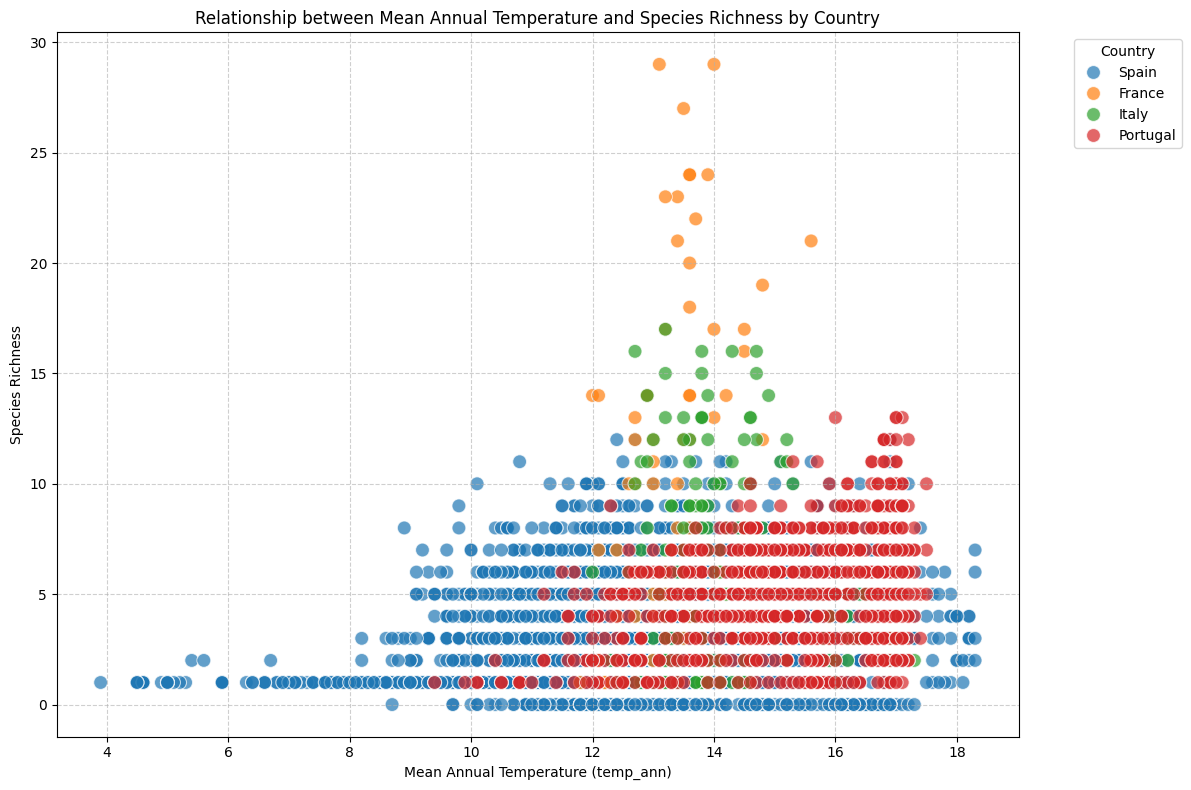

In [17]:
# Prepare data, ensuring no missing values in the relevant columns
plot_data = df[['temp_ann', 'Species_Richness', 'Country']].dropna()

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=plot_data,
    x='temp_ann',
    y='Species_Richness',
    hue='Country',  # Differentiate by country
    palette='tab10', # Use a distinct palette for countries
    s=100,           # Size of the points
    alpha=0.7        # Transparency for overlapping points
)

plt.title('Relationship between Mean Annual Temperature and Species Richness by Country')
plt.xlabel('Mean Annual Temperature (temp_ann)')
plt.ylabel('Species Richness')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside to avoid overlap
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()